In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dcgan-mnist/DCGAN-MNIST-LATEST/DCGAN-MNIST/Generated/generated_image_1260.png
/kaggle/input/dcgan-mnist/DCGAN-MNIST-LATEST/DCGAN-MNIST/Generated/generated_image_306.png
/kaggle/input/dcgan-mnist/DCGAN-MNIST-LATEST/DCGAN-MNIST/Generated/generated_image_4456.png
/kaggle/input/dcgan-mnist/DCGAN-MNIST-LATEST/DCGAN-MNIST/Generated/generated_image_2710.png
/kaggle/input/dcgan-mnist/DCGAN-MNIST-LATEST/DCGAN-MNIST/Generated/generated_image_4380.png
/kaggle/input/dcgan-mnist/DCGAN-MNIST-LATEST/DCGAN-MNIST/Generated/generated_image_3290.png
/kaggle/input/dcgan-mnist/DCGAN-MNIST-LATEST/DCGAN-MNIST/Generated/generated_image_8012.png
/kaggle/input/dcgan-mnist/DCGAN-MNIST-LATEST/DCGAN-MNIST/Generated/generated_image_1792.png
/kaggle/input/dcgan-mnist/DCGAN-MNIST-LATEST/DCGAN-MNIST/Generated/generated_image_5603.png
/kaggle/input/dcgan-mnist/DCGAN-MNIST-LATEST/DCGAN-MNIST/Generated/generated_image_4482.png
/kaggle/input/dcgan-mnist/DCGAN-MNIST-LATEST/DCGAN-MNIST/Generated/generated_imag

# Chapter 4 숫자 이미지 생성하기 p266


In [2]:
!pip install -q torchinfo



import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

import os
from torchvision.datasets.mnist import MNIST

from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import torch
from torch import nn, optim
import torchvision
from torchvision.utils import make_grid
from torchinfo import summary

is_cuda = torch.cuda.is_available()
device = torch.device("cuda" if is_cuda else "cpu")
print(is_cuda, device)

True cuda


In [3]:
seed = 130
random.seed(seed)         # python seed
np.random.seed(seed)      # numpy seed
torch.manual_seed(seed)   # torch seed
if device == 'cuda':
  torch.cuda.manual_seed_all(seed)  # gpu seed

## 4.2 데이터와 데이터셋


100%|██████████| 9.91M/9.91M [00:00<00:00, 42.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.22MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.88MB/s]


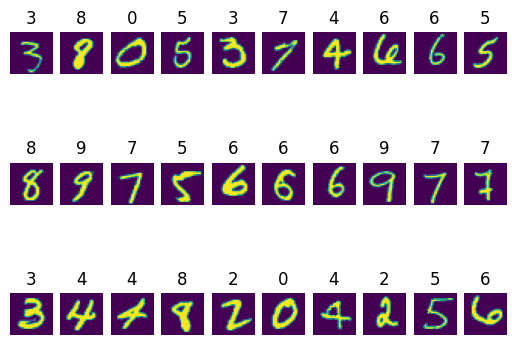

In [4]:
base_dir = "dataset"

transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
])
mnist = DataLoader(MNIST(base_dir, train=True, download=True, transform=transform),
                   batch_size=30, shuffle=True)

for images, labels in mnist:
  for i in range(len(images)):
    plt.subplot(3, 10, i+1)
    plt.title(labels[i].item())
    plt.imshow(images[i].squeeze())
    plt.axis("off")
  break
     

## 4.3 CGAN 모델


In [5]:
class Discriminator(nn.Module):
  def __init__(self):
    super(Discriminator, self).__init__()

    self.label_emb = nn.Embedding(10, 10)
    self.model = nn.Sequential(
      nn.Linear(794, 1024),
      nn.ReLU(),
      nn.Linear(1024, 512),
      nn.ReLU(),
      nn.Linear(512, 256),
      nn.ReLU(),
      nn.Linear(256, 1),
      nn.Sigmoid()
    )

  def forward(self, x, labels):
    x = nn.Flatten()(x)
    c = self.label_emb(labels)
    x = torch.cat([x, c], dim=1)
    out = self.model(x)
    return out.squeeze()

      

In [6]:
class Generator(nn.Module):
  def __init__(self):
    super().__init__()

    self.label_emb = nn.Embedding(10, 10)
    self.model = nn.Sequential(
      nn.Linear(110, 256),
      nn.LeakyReLU(0.2),
      nn.Linear(256, 512),
      nn.LeakyReLU(0.2),
      nn.Linear(512, 1024),
      nn.LeakyReLU(0.2),
      nn.Linear(1024, 784),
      nn.Tanh()
    )

  def forward(self, z, labels):
    z = nn.Flatten()(z)
    c = self.label_emb(labels)
    x = torch.cat([z, c], 1)
    out = self.model(x)
    return out.reshape(-1, 28, 28)

In [7]:
dummy_z = torch.randn(1, 100)
dummy_c = torch.randint(0, 10, (1,))
summary(Generator(), input_data=(dummy_z, dummy_c))

Layer (type:depth-idx)                   Output Shape              Param #
Generator                                [1, 28, 28]               --
├─Embedding: 1-1                         [1, 10]                   100
├─Sequential: 1-2                        [1, 784]                  --
│    └─Linear: 2-1                       [1, 256]                  28,416
│    └─LeakyReLU: 2-2                    [1, 256]                  --
│    └─Linear: 2-3                       [1, 512]                  131,584
│    └─LeakyReLU: 2-4                    [1, 512]                  --
│    └─Linear: 2-5                       [1, 1024]                 525,312
│    └─LeakyReLU: 2-6                    [1, 1024]                 --
│    └─Linear: 2-7                       [1, 784]                  803,600
│    └─Tanh: 2-8                         [1, 784]                  --
Total params: 1,489,012
Trainable params: 1,489,012
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.49
Input size (MB): 0.

In [8]:


dummy_x = torch.randn(1, 28, 28)
dummy_c = torch.randint(0, 10, (1,))
summary(Discriminator(), input_data=(dummy_x, dummy_c))

Layer (type:depth-idx)                   Output Shape              Param #
Discriminator                            --                        --
├─Embedding: 1-1                         [1, 10]                   100
├─Sequential: 1-2                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 1024]                 814,080
│    └─ReLU: 2-2                         [1, 1024]                 --
│    └─Linear: 2-3                       [1, 512]                  524,800
│    └─ReLU: 2-4                         [1, 512]                  --
│    └─Linear: 2-5                       [1, 256]                  131,328
│    └─ReLU: 2-6                         [1, 256]                  --
│    └─Linear: 2-7                       [1, 1]                    257
│    └─Sigmoid: 2-8                      [1, 1]                    --
Total params: 1,470,565
Trainable params: 1,470,565
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.47
Input size (MB): 0.00


## 4.4 모델 학습


In [9]:
def generator_train_step(batch_size, discriminator, generator,
                         g_optimizer, criterion, device):
  z = torch.randn(batch_size, 100).to(device)
  fake_labels = torch.randint(0, 10, (batch_size,)).to(device)

  g_optimizer.zero_grad()

  fake_images = generator(z, fake_labels)
  validity = discriminator(fake_images, fake_labels)

  g_loss = criterion(validity, torch.ones(batch_size).to(device))
  g_loss.backward()
  g_optimizer.step()

  return g_loss.item()

In [10]:
def discriminator_train_step(batch_size, discriminator, generator,
                             d_optimizer, criterion,
                             images, labels, device):
  d_optimizer.zero_grad()

  # train with real images
  real_validity = discriminator(images.to(device), labels.to(device))
  real_loss = criterion(real_validity, torch.ones(batch_size).to(device))

  # train with fake images
  z = torch.randn(batch_size, 100).to(device)
  fake_labels = torch.randint(0, 10, (batch_size,)).to(device)

  fake_images = generator(z, fake_labels)
  fake_validity = discriminator(fake_images, fake_labels)
  fake_loss = criterion(fake_validity, torch.zeros(batch_size).to(device))

  d_loss = real_loss + fake_loss
  d_loss.backward()
  d_optimizer.step()

  return d_loss.item()

In [11]:
def train(generator, discriminator, dataloader, criterion,
          g_optimizer, d_optimizer, epoch, device, n_critic=3):

  generator.train()
  discriminator.train()

  running_g_loss = 0
  running_d_loss = 0

  with tqdm(dataloader) as pbar:
    for i, (images, labels) in enumerate(pbar):

      batch_size = len(images)

      # train discriminator in n_critic
      d_loss = 0
      for _ in range(n_critic):
        d_loss += discriminator_train_step(batch_size, discriminator,
                                           generator, d_optimizer, criterion,
                                           images, labels, device)
      d_loss /= n_critic

      # train generator
      g_loss = generator_train_step(batch_size, discriminator, generator,
                                    g_optimizer, criterion, device)

      running_d_loss += d_loss
      running_g_loss += g_loss
      pbar.set_postfix(d_loss=d_loss, g_loss=g_loss)

  return running_d_loss/len(dataloader), running_g_loss/len(dataloader)

In [12]:
def validation(generator, epoch, device):
  generator.eval()

  z = torch.randn(10, 100).to(device)
  labels = torch.arange(0, 10).to(device)
  images = generator(z, labels).unsqueeze(1)

  grid = make_grid(images, nrow=10, normalize=True)

  fig, ax = plt.subplots(figsize=(10, 1))
  ax.imshow(grid.permute(1, 2, 0).cpu(), cmap='binary')
  ax.axis('off')
  plt.show()

Epoch: 0


100%|██████████| 938/938 [00:21<00:00, 43.03it/s, d_loss=0.0647, g_loss=9.53]  


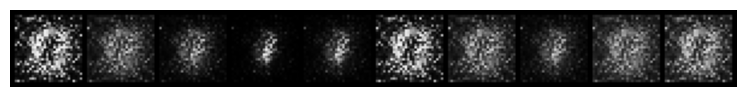

Epoch: 1


100%|██████████| 938/938 [00:21<00:00, 44.48it/s, d_loss=0.0282, g_loss=11.6]  


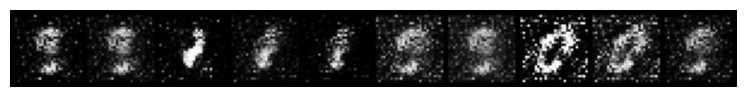

Epoch: 2


100%|██████████| 938/938 [00:21<00:00, 44.66it/s, d_loss=0.00694, g_loss=11]   


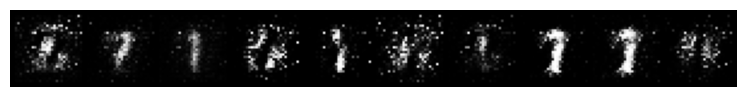

Epoch: 3


100%|██████████| 938/938 [00:20<00:00, 45.12it/s, d_loss=0.0407, g_loss=11.3]  


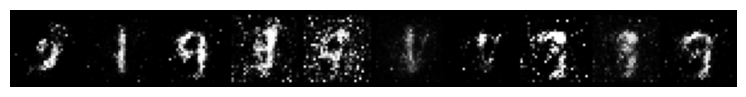

Epoch: 4


100%|██████████| 938/938 [00:20<00:00, 45.11it/s, d_loss=0.0338, g_loss=9.68] 


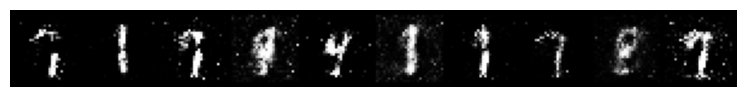

Epoch: 5


100%|██████████| 938/938 [00:20<00:00, 44.72it/s, d_loss=0.00462, g_loss=9.63]


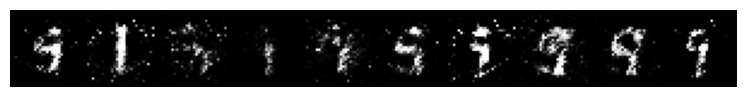

Epoch: 6


100%|██████████| 938/938 [00:20<00:00, 45.11it/s, d_loss=0.0656, g_loss=7.73] 


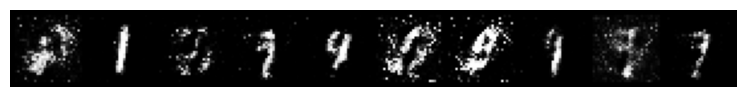

Epoch: 7


100%|██████████| 938/938 [00:20<00:00, 44.71it/s, d_loss=0.0683, g_loss=8.44] 


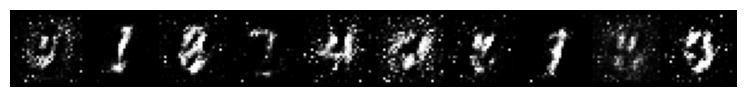

Epoch: 8


100%|██████████| 938/938 [00:21<00:00, 44.20it/s, d_loss=0.0765, g_loss=4.5] 


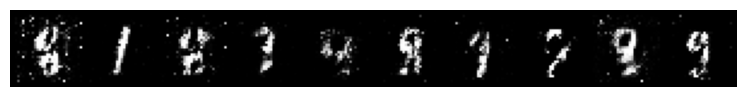

Epoch: 9


100%|██████████| 938/938 [00:21<00:00, 44.66it/s, d_loss=0.537, g_loss=3.69] 


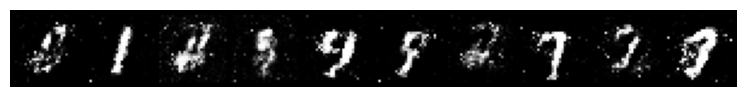

Epoch: 10


100%|██████████| 938/938 [00:20<00:00, 45.33it/s, d_loss=0.366, g_loss=7.9]  


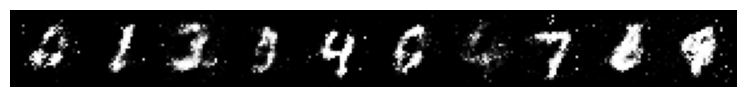

Epoch: 11


100%|██████████| 938/938 [00:21<00:00, 44.57it/s, d_loss=0.33, g_loss=4.06]  


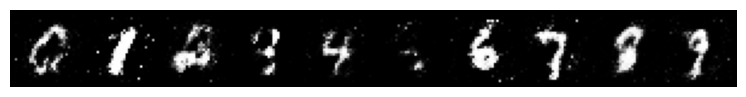

Epoch: 12


100%|██████████| 938/938 [00:21<00:00, 44.46it/s, d_loss=0.259, g_loss=4.99] 


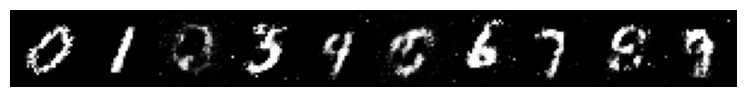

Epoch: 13


100%|██████████| 938/938 [00:20<00:00, 44.83it/s, d_loss=0.337, g_loss=3.11]


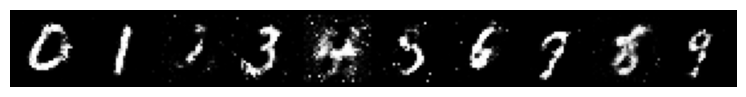

Epoch: 14


100%|██████████| 938/938 [00:20<00:00, 45.17it/s, d_loss=0.219, g_loss=3.58]


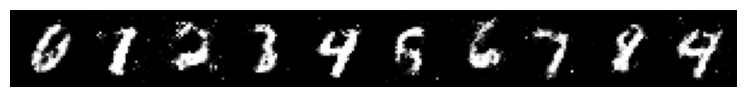

Epoch: 15


100%|██████████| 938/938 [00:20<00:00, 45.16it/s, d_loss=0.553, g_loss=3.02]


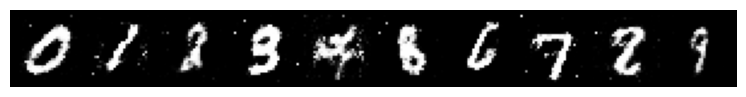

Epoch: 16


100%|██████████| 938/938 [00:21<00:00, 44.55it/s, d_loss=0.329, g_loss=3.42]


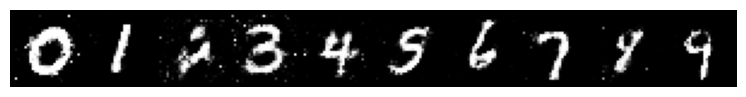

Epoch: 17


100%|██████████| 938/938 [00:21<00:00, 44.38it/s, d_loss=0.58, g_loss=2.7]  


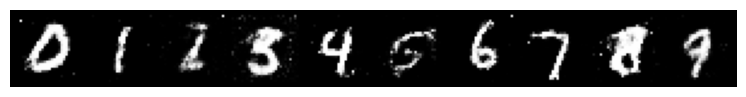

Epoch: 18


100%|██████████| 938/938 [00:21<00:00, 44.20it/s, d_loss=0.448, g_loss=3.35]


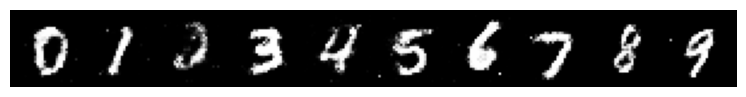

Epoch: 19


100%|██████████| 938/938 [00:21<00:00, 44.43it/s, d_loss=0.553, g_loss=2.76]


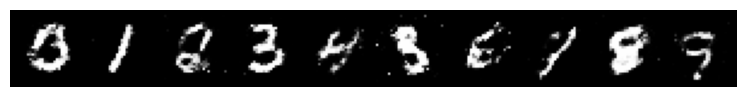

Epoch: 20


100%|██████████| 938/938 [00:21<00:00, 44.66it/s, d_loss=0.59, g_loss=2.34] 


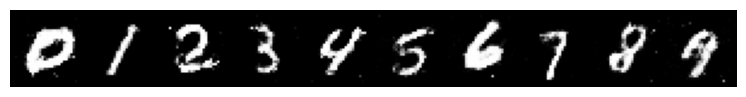

Epoch: 21


100%|██████████| 938/938 [00:21<00:00, 44.30it/s, d_loss=0.715, g_loss=2.06]


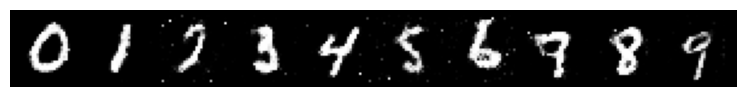

Epoch: 22


100%|██████████| 938/938 [00:20<00:00, 45.39it/s, d_loss=0.571, g_loss=2.36]


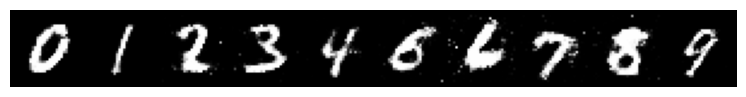

Epoch: 23


100%|██████████| 938/938 [00:21<00:00, 44.50it/s, d_loss=0.542, g_loss=2.14]


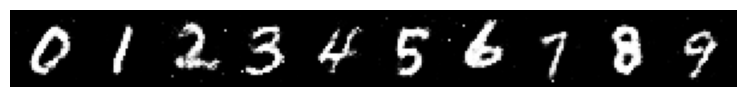

Epoch: 24


100%|██████████| 938/938 [00:20<00:00, 45.12it/s, d_loss=0.73, g_loss=1.71] 


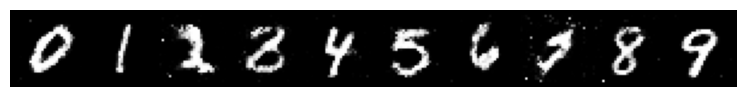

Epoch: 25


100%|██████████| 938/938 [00:21<00:00, 44.62it/s, d_loss=0.63, g_loss=2.7]  


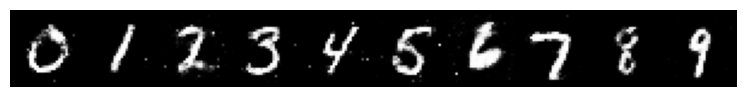

Epoch: 26


100%|██████████| 938/938 [00:20<00:00, 45.40it/s, d_loss=0.901, g_loss=1.77]


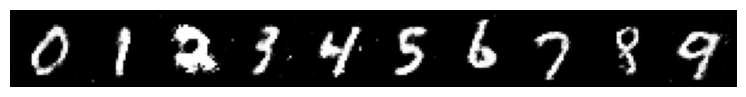

Epoch: 27


100%|██████████| 938/938 [00:20<00:00, 45.06it/s, d_loss=0.558, g_loss=2.19]


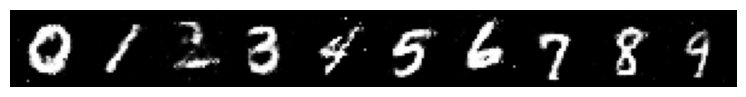

Epoch: 28


100%|██████████| 938/938 [00:20<00:00, 45.14it/s, d_loss=0.575, g_loss=2.37]


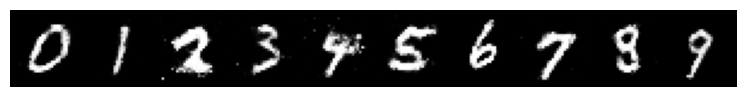

Epoch: 29


100%|██████████| 938/938 [00:21<00:00, 44.31it/s, d_loss=0.629, g_loss=2.66]


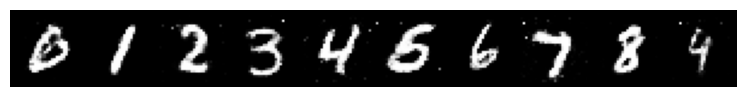

Save Model: 0.6756364102577941


In [13]:

EPOCH = 30
BATCH_SIZE = 64
NUM_WORKERS = 2
LR = 0.0001

transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
])
train_loader = DataLoader(
    MNIST(base_dir, train=True, download=True, transform=transform),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

generator = Generator().to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss().to(device)
g_optimizer = torch.optim.Adam(generator.parameters(), lr=LR)
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=LR)

# Start Training
for epoch in range(EPOCH):
  print(f"Epoch: {epoch}")

  gloss, dloss = train(generator, discriminator, train_loader, criterion,
                       g_optimizer, d_optimizer, epoch, device)

  validation(generator, epoch, device)

print(f"Save Model: {gloss}")
torch.save(generator.state_dict(), "last.pth")

## 4.5 추론


(-0.5, 301.5, 301.5, -0.5)

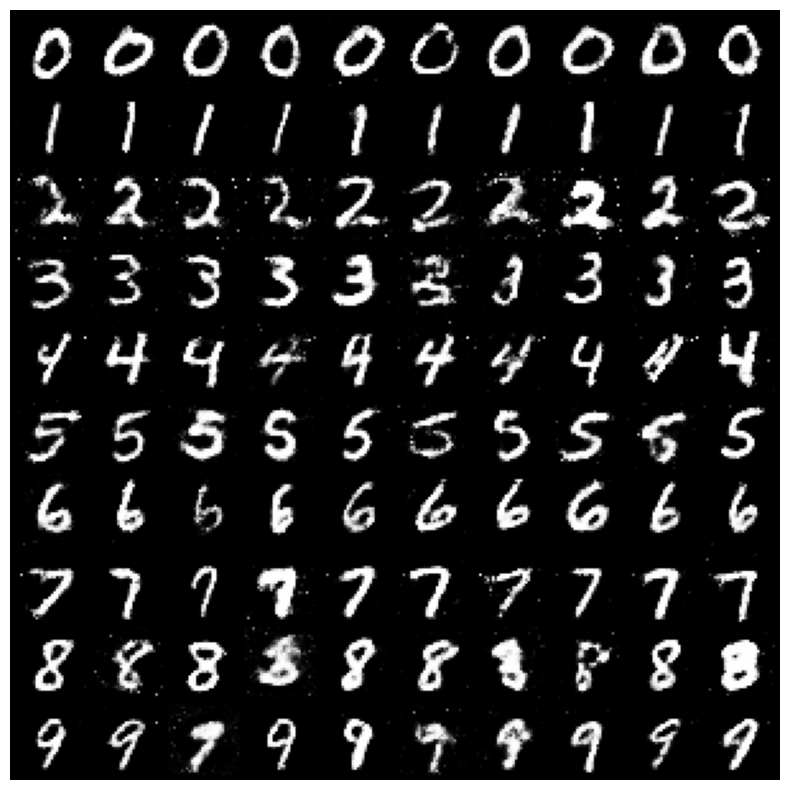

In [14]:

z = torch.randn(100, 100).to(device)
labels = (torch.arange(0, 100) // 10).cuda()

with torch.no_grad():
  images = generator(z, labels).unsqueeze(1)

grid = make_grid(images, nrow=10, normalize=True)

fig, ax = plt.subplots(figsize=(10,10))
ax.imshow(grid.permute(1, 2, 0).cpu(), cmap='binary')
ax.axis('off')